Variable is a characteristic number or quantity that can be measured or counted

Eg
1. Age
2. Gender
3. Income
4. Country
etc..

values of a variable can vary

variable types
1. Numerical
2. Categorical

Numerical Variable types
* Continous -> all real valued numbers (within some range)
* discrete -> whole numbers

Categorical Types -> values selected from a group of values
* Nominal
* Ordinal
* Data / time

Some caveats
* categorical variables can have numeric values
* id variables -> these have numbers but these numbers mean nothing

Mixed Variables

these contain both numerical and categorical values

## Numerical Variables demo

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = Path().resolve().parent / "data"
data_path = data_dir / "loan.csv"
data_path

PosixPath('/Users/mokshmanchandani/Documents/Codes/DATA_SCIENCE/practice/data-science/data/loan.csv')

In [3]:
df = pd.read_csv(data_path)
df_numerical = df.select_dtypes(include='number')
df_numerical.columns

Index(['customer_id', 'disbursed_amount', 'interest', 'income', 'target',
       'number_open_accounts', 'number_credit_lines_12'],
      dtype='object')

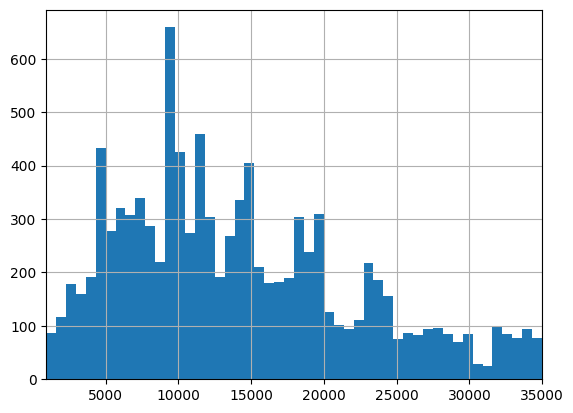

In [4]:
plt.hist(df_numerical['disbursed_amount'], bins=50)
plt.xlim([df_numerical['disbursed_amount'].min(), df_numerical['disbursed_amount'].max()])
plt.grid()

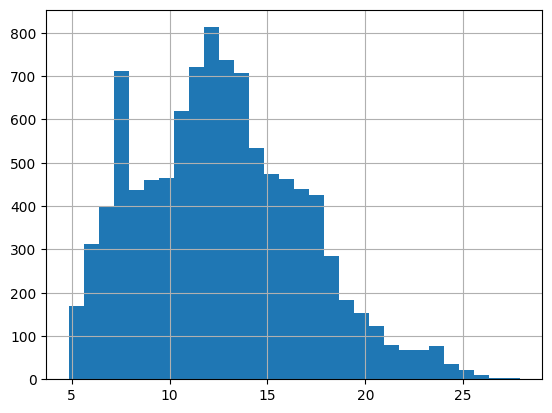

In [5]:
plt.hist(df_numerical['interest'], bins=30)
plt.grid()

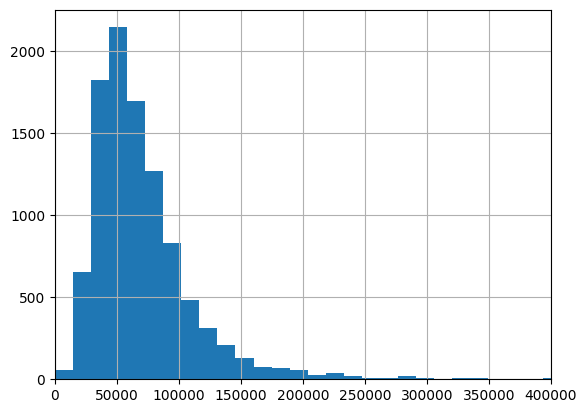

In [6]:
plt.hist(df_numerical['income'], bins=150);
plt.xlim([0, 400_000])
plt.grid();

In [7]:
# check for range of values
# this is a discreate value
df_numerical['target'].unique()

array([0, 1])

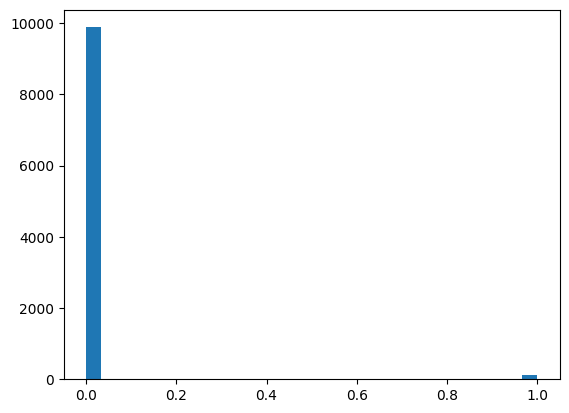

In [8]:
# plotting histogram for discreate values
# this is a special type of discreate value -> binary value since there are only two possible outcomes (1,0)
plt.hist(df_numerical['target'], bins=30);

In [9]:
# this is discreate variable
df_numerical['number_open_accounts'].unique()

array([ 4., 13.,  8., 20., 14.,  5.,  9., 18., 16., 17., 12., 15.,  6.,
       10., 11.,  7., 21., 19., 26.,  2., 22., 27., 23., 25., 24., 28.,
        3., 30., 41., 32., 33., 31., 29., 37., 49., 34., 35., 38.,  1.,
       36., 42., 47., 40., 44., 43.])

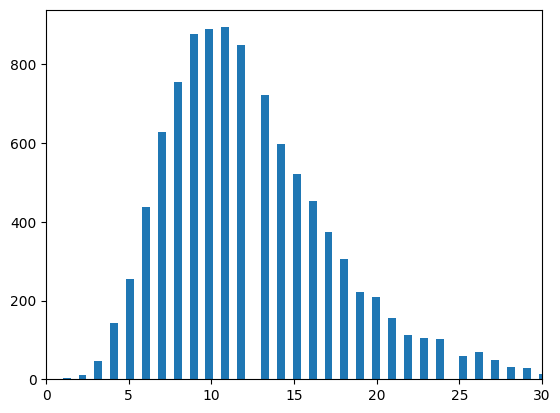

In [10]:
plt.hist(df_numerical['number_open_accounts'], bins=100)
plt.xlim([0,30]);

[nan  2.  4.  1.  0.  3.  5.  6.]


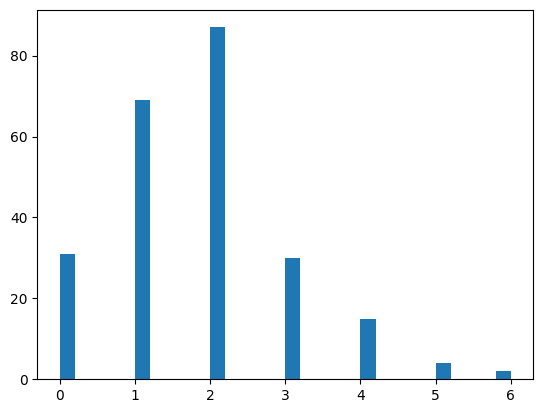

In [11]:
print(df_numerical['number_credit_lines_12'].unique())

plt.hist(df_numerical['number_credit_lines_12'], bins=30);

## Categorical Variables

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = Path().resolve().parent / "data"
data_dir

PosixPath('/Users/mokshmanchandani/Documents/Codes/DATA_SCIENCE/practice/data-science/data')

In [3]:
data_path = data_dir / "loan.csv"
df = pd.read_csv(data_path)
df.columns

Index(['customer_id', 'disbursed_amount', 'interest', 'market', 'employment',
       'time_employed', 'householder', 'income', 'date_issued', 'target',
       'loan_purpose', 'number_open_accounts', 'date_last_payment',
       'number_credit_lines_12'],
      dtype='object')

In [4]:
# show non-numerical information
df.select_dtypes(exclude='number').head()

,market,employment,time_employed,householder,date_issued,loan_purpose,date_last_payment
0,C,Teacher,<=5 years,RENT,2013-06-11,Debt consolidation,2016-01-14
1,B,Accountant,<=5 years,OWNER,2014-05-08,Car purchase,2016-01-25
2,A,Statistician,<=5 years,RENT,2013-10-26,Debt consolidation,2014-09-26
3,A,Other,<=5 years,RENT,2015-08-20,Debt consolidation,2016-01-26
4,E,Bus driver,>5 years,RENT,2014-07-22,Debt consolidation,2016-01-11


In [5]:
# show non-numerical information
df.select_dtypes(exclude='number').describe()

,market,employment,time_employed,householder,date_issued,loan_purpose,date_last_payment
count,10000,9389,9471,10000,10000,10000,10000
unique,5,11,2,3,1642,8,1071
top,B,Civil Servant,>5 years,MORTGAGE,2015-10-16,Debt consolidation,2016-01-02
freq,2846,884,5057,4957,28,8214,225


In [6]:
# show non-numerical information
df.select_dtypes(exclude='number').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   market             10000 non-null  object
 1   employment         9389 non-null   object
 2   time_employed      9471 non-null   object
 3   householder        10000 non-null  object
 4   date_issued        10000 non-null  object
 5   loan_purpose       10000 non-null  object
 6   date_last_payment  10000 non-null  object
dtypes: object(7)
memory usage: 547.0+ KB


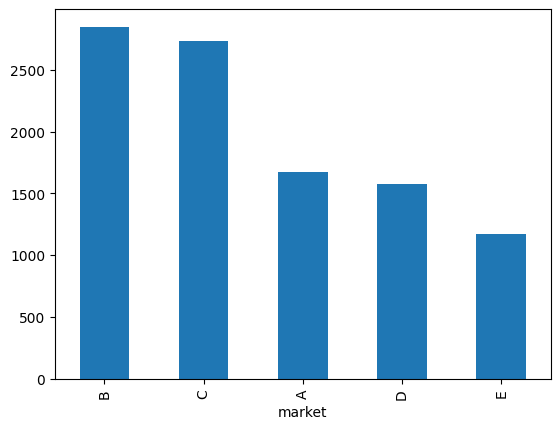

In [7]:
df['market'].value_counts().plot.bar();

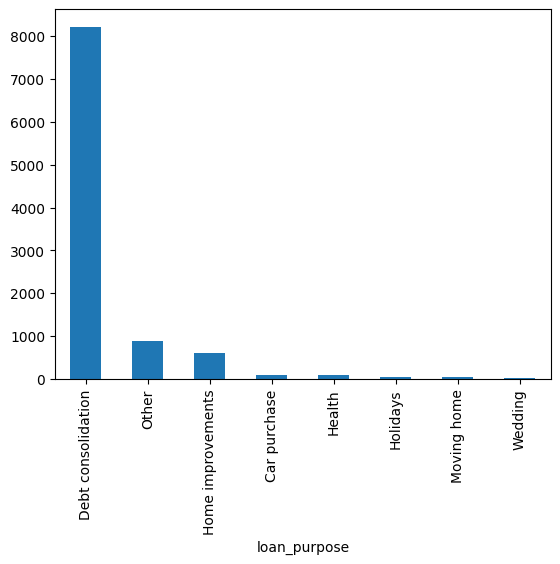

In [8]:
df['loan_purpose'].value_counts().plot.bar();

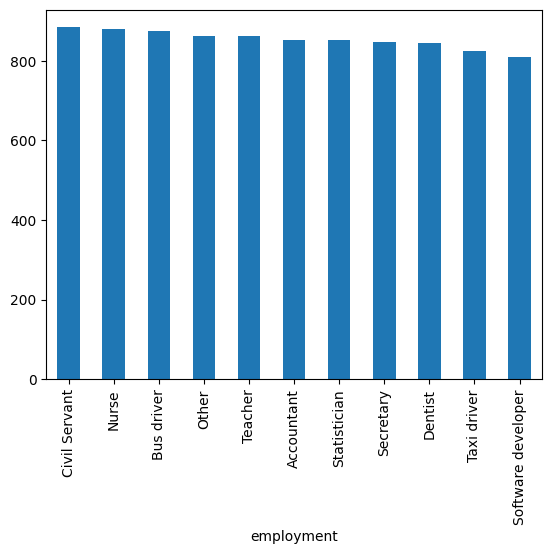

In [9]:
df['employment'].value_counts().plot.bar();

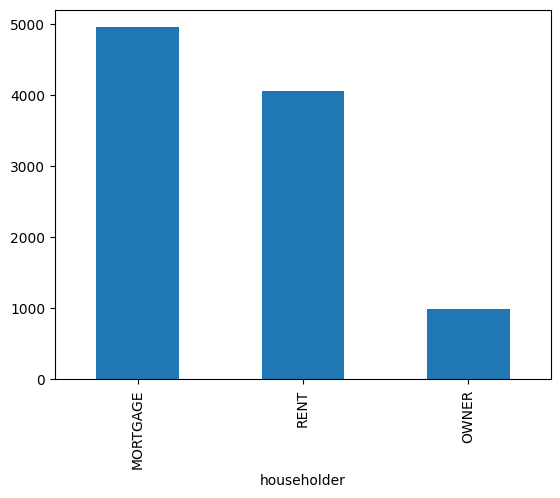

In [10]:
df['householder'].value_counts().plot.bar();

## Visualizing Time series data

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = Path().resolve().parent / "data"

In [3]:
data_path = data_dir / "loan.csv"
df = pd.read_csv(data_path)

df.select_dtypes(exclude='number').columns

Index(['market', 'employment', 'time_employed', 'householder', 'date_issued',
       'loan_purpose', 'date_last_payment'],
      dtype='object')

In [4]:
df.select_dtypes(exclude='number').head()

,market,employment,time_employed,householder,date_issued,loan_purpose,date_last_payment
0,C,Teacher,<=5 years,RENT,2013-06-11,Debt consolidation,2016-01-14
1,B,Accountant,<=5 years,OWNER,2014-05-08,Car purchase,2016-01-25
2,A,Statistician,<=5 years,RENT,2013-10-26,Debt consolidation,2014-09-26
3,A,Other,<=5 years,RENT,2015-08-20,Debt consolidation,2016-01-26
4,E,Bus driver,>5 years,RENT,2014-07-22,Debt consolidation,2016-01-11


In [5]:
# from above it is observed that date_issued and date_last_payment should be parsed as dates lets look at their dtypes

df[['date_issued', 'date_last_payment']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date_issued        10000 non-null  object
 1   date_last_payment  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [6]:
# from above output they are parsed as string values we can change this as follows
df['date_issued_dt'] = pd.to_datetime(df['date_issued'])
df['date_last_payment_dt'] = pd.to_datetime(df['date_last_payment'])

In [7]:
df[['date_issued', 'date_last_payment', 'date_issued_dt', 'date_last_payment_dt']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_issued           10000 non-null  object        
 1   date_last_payment     10000 non-null  object        
 2   date_issued_dt        10000 non-null  datetime64[ns]
 3   date_last_payment_dt  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 312.6+ KB


In [8]:
# we can see that the columns are added with date time format

df[['date_issued', 'date_last_payment','date_issued_dt','date_last_payment_dt']].head()

,date_issued,date_last_payment,date_issued_dt,date_last_payment_dt
0,2013-06-11,2016-01-14,2013-06-11,2016-01-14
1,2014-05-08,2016-01-25,2014-05-08,2016-01-25
2,2013-10-26,2014-09-26,2013-10-26,2014-09-26
3,2015-08-20,2016-01-26,2015-08-20,2016-01-26
4,2014-07-22,2016-01-11,2014-07-22,2016-01-11


In [9]:
# they look the same but we get more from the dt columns using the dt attributes

df['month_issued'] = df['date_issued_dt'].dt.month
df['year_issued'] = df['date_issued_dt'].dt.year

df.head()

,customer_id,disbursed_amount,interest,market,employment,time_employed,householder,income,date_issued,target,loan_purpose,number_open_accounts,date_last_payment,number_credit_lines_12,date_issued_dt,date_last_payment_dt,month_issued,year_issued
0,0,23201.5,15.4840,C,Teacher,<=5 years,RENT,84600.0,2013-06-11,0,Debt consolidation,4.0,2016-01-14,NaN,2013-06-11,2016-01-14,6,2013
1,1,7425.0,11.2032,B,Accountant,<=5 years,OWNER,102000.0,2014-05-08,0,Car purchase,13.0,2016-01-25,NaN,2014-05-08,2016-01-25,5,2014
2,2,11150.0,8.5100,A,Statistician,<=5 years,RENT,69840.0,2013-10-26,0,Debt consolidation,8.0,2014-09-26,NaN,2013-10-26,2014-09-26,10,2013
3,3,7600.0,5.8656,A,Other,<=5 years,RENT,100386.0,2015-08-20,0,Debt consolidation,20.0,2016-01-26,NaN,2015-08-20,2016-01-26,8,2015
4,4,31960.0,18.7392,E,Bus driver,>5 years,RENT,95040.0,2014-07-22,0,Debt consolidation,14.0,2016-01-11,NaN,2014-07-22,2016-01-11,7,2014


<Axes: xlabel='year_issued,month_issued'>

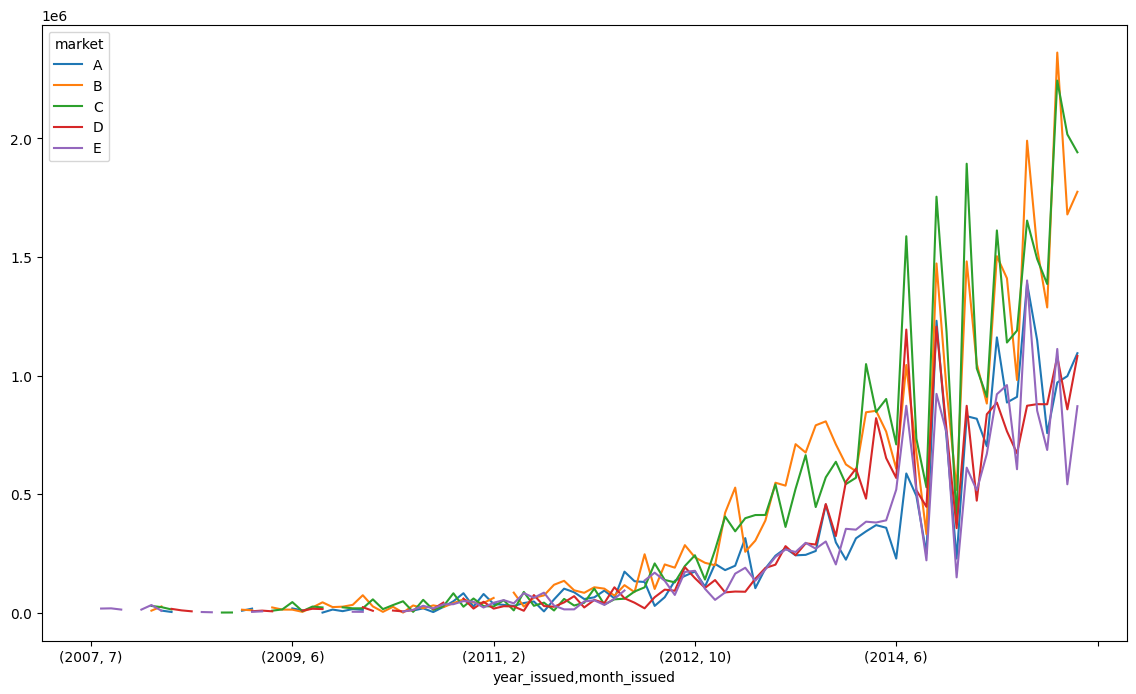

In [16]:
df.groupby(['year_issued', 'month_issued', 'market'])['disbursed_amount'].sum().unstack().plot(
    figsize=(14,8)
)